# Autocomplete and Autocorrect Data Analytics

## Objective

This project analyzes the efficiency and accuracy of autocomplete and autocorrect algorithms using Natural Language Processing (NLP). It implements a frequency-based bigram model for autocomplete and an edit-distance-based spell checker for autocorrect.

**Internship:** Oasis Infobyte Data Analytics Internship – Task 5

In [6]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\userp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\userp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\userp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import string

import pandas as pd
import numpy as np

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import bigrams
from nltk.probability import FreqDist

from spellchecker import SpellChecker

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict

# Download required NLTK resources (only first time)
nltk.download("punkt")
nltk.download("stopwords")

# Create folders if they don't exist
os.makedirs("images", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\userp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\userp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load the Text Corpus

In [8]:
with open("corpus.txt", "r", encoding="utf-8") as file:
    text = file.read()

print("Total Characters:", len(text))
print(text[:500])

Total Characters: 0



# NLP Preprocessing

The text is converted to lowercase, punctuation is removed, tokenization is performed, and stopwords are removed to prepare the corpus for autocomplete and autocorrect analysis.

In [9]:
# Convert to lowercase
text = text.lower()

# Remove punctuation
text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

# Remove numbers
text = re.sub(r"\d+", "", text)

# Tokenize
tokens = word_tokenize(text)

print("Total Tokens:", len(tokens))
print(tokens[:20])

Total Tokens: 0
[]


In [10]:
stop_words = set(stopwords.words("english"))

words = [
    word
    for word in tokens
    if word not in stop_words and len(word) > 1
]

print("Words after preprocessing:", len(words))
print(words[:20])

Words after preprocessing: 0
[]


# Word Frequency Analysis

In [11]:
word_freq = Counter(words)

top20 = word_freq.most_common(20)

top20_df = pd.DataFrame(
    top20,
    columns=["Word", "Frequency"]
)

top20_df

,Word,Frequency


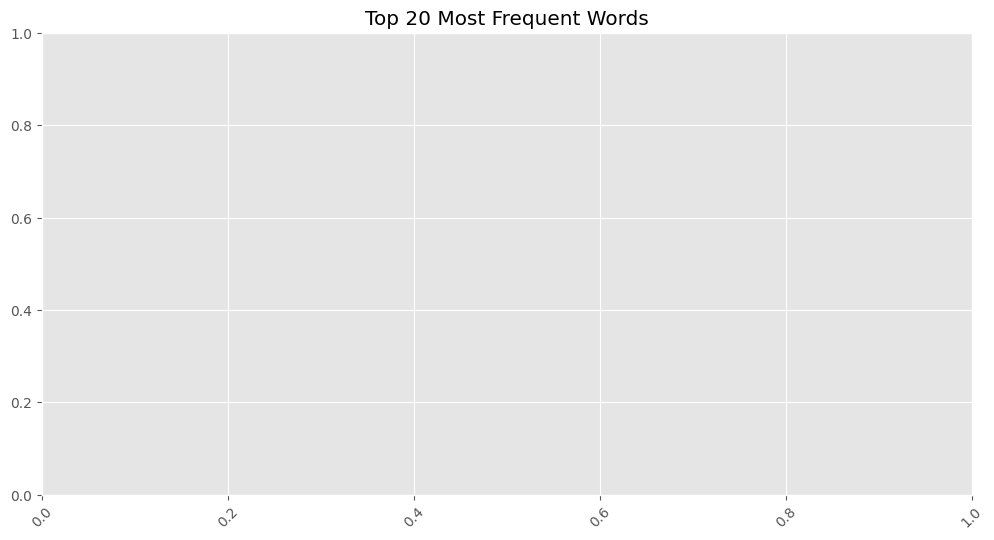

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top20_df,
    x="Word",
    y="Frequency",
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Top 20 Most Frequent Words")

plt.savefig(
    "images/top_20_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Autocomplete using a Bigram Model

A bigram model predicts the next word based on the current word. The model is built using word frequencies from the text corpus.

In [13]:
from collections import defaultdict

bigram_model = defaultdict(Counter)

for first, second in bigrams(words):
    bigram_model[first][second] += 1

print("Bigram model created successfully!")

Bigram model created successfully!


In [14]:
def autocomplete(word, n=3):
    word = word.lower()

    if word not in bigram_model:
        return []

    return [
        next_word
        for next_word, _ in bigram_model[word].most_common(n)
    ]

In [15]:
test_words = [
    "alice",
    "little",
    "queen",
    "king",
    "rabbit",
    "white",
    "mock",
    "gryphon",
    "cat",
    "hatter"
]

for word in test_words:
    print(f"{word}  --->  {autocomplete(word)}")

alice  --->  []
little  --->  []
queen  --->  []
king  --->  []
rabbit  --->  []
white  --->  []
mock  --->  []
gryphon  --->  []
cat  --->  []
hatter  --->  []


# Autocomplete Results

The following table shows the top three predicted words for each test prefix.

In [16]:
autocomplete_results = []

for word in test_words:
    predictions = autocomplete(word)

    autocomplete_results.append({
        "Input Word": word,
        "Predictions": ", ".join(predictions)
    })

autocomplete_df = pd.DataFrame(autocomplete_results)

autocomplete_df

,Input Word,Predictions
0,alice,
1,little,
2,queen,
3,king,
4,rabbit,
5,white,
6,mock,
7,gryphon,
8,cat,
9,hatter,


In [17]:
autocomplete_df.to_csv(
    "outputs/autocomplete_results.csv",
    index=False
)

print("Autocomplete results saved successfully!")

Autocomplete results saved successfully!


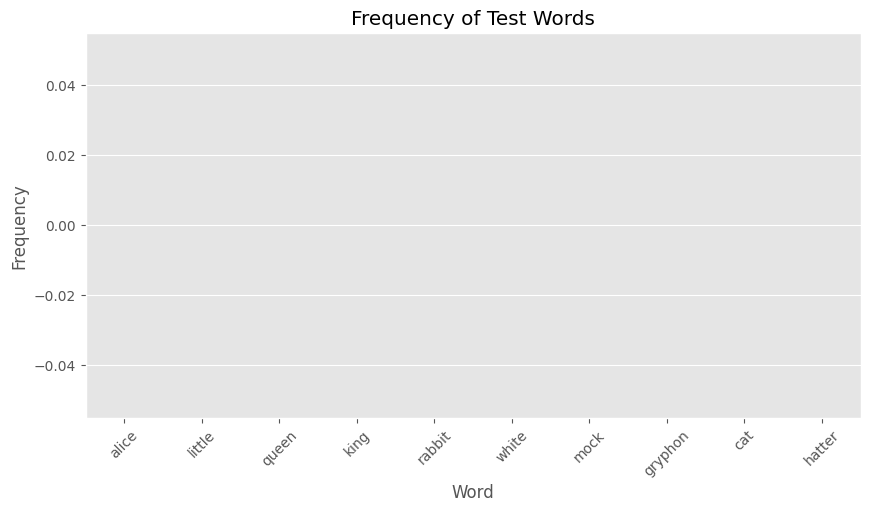

In [18]:
counts = []

for word in test_words:
    counts.append(word_freq[word])

plot_df = pd.DataFrame({
    "Word": test_words,
    "Frequency": counts
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=plot_df,
    x="Word",
    y="Frequency",
    palette="viridis"
)

plt.title("Frequency of Test Words")

plt.xticks(rotation=45)

plt.show()

# Autocorrect using PySpellChecker

The autocorrect system uses the **PySpellChecker** library to identify and correct misspelled words based on edit distance and word frequency.

In [19]:
spell = SpellChecker()

print("SpellChecker initialized successfully!")

SpellChecker initialized successfully!


In [20]:
misspelled_words = [
    "recieve",
    "adress",
    "acommodate",
    "beleive",
    "definately",
    "enviroment",
    "goverment",
    "happend",
    "langauge",
    "neccessary",
    "occured",
    "seperate",
    "sucess",
    "tommorow",
    "untill",
    "wierd",
    "writting",
    "acheive",
    "comming",
    "freind"
]

In [21]:
corrected_words = []

for word in misspelled_words:
    correction = spell.correction(word)

    corrected_words.append({
        "Misspelled": word,
        "Corrected": correction
    })

autocorrect_df = pd.DataFrame(corrected_words)

autocorrect_df

,Misspelled,Corrected
0,recieve,receive
1,adress,dress
2,acommodate,accommodate
3,beleive,believe
4,definately,definitely
5,enviroment,environment
6,goverment,government
7,happend,happened
8,langauge,language
9,neccessary,necessary


In [22]:
autocorrect_df.to_csv(
    "outputs/autocorrect_results.csv",
    index=False
)

print("Autocorrect results saved successfully!")

Autocorrect results saved successfully!


# Accuracy Evaluation

Evaluate the correction accuracy using known expected spellings.

In [23]:
expected = [
    "receive",
    "address",
    "accommodate",
    "believe",
    "definitely",
    "environment",
    "government",
    "happened",
    "language",
    "necessary",
    "occurred",
    "separate",
    "success",
    "tomorrow",
    "until",
    "weird",
    "writing",
    "achieve",
    "coming",
    "friend"
]

In [24]:
correct = 0

for pred, actual in zip(
    autocorrect_df["Corrected"],
    expected
):
    if pred == actual:
        correct += 1

accuracy = correct / len(expected)

print(f"Autocorrect Accuracy: {accuracy:.2%}")

Autocorrect Accuracy: 95.00%


In [25]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

y_true = [1] * len(expected)

y_pred = [
    1 if pred == actual else 0
    for pred, actual in zip(
        autocorrect_df["Corrected"],
        expected
    )
]

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 1.0
Recall    : 0.95
F1 Score  : 0.9743589743589743


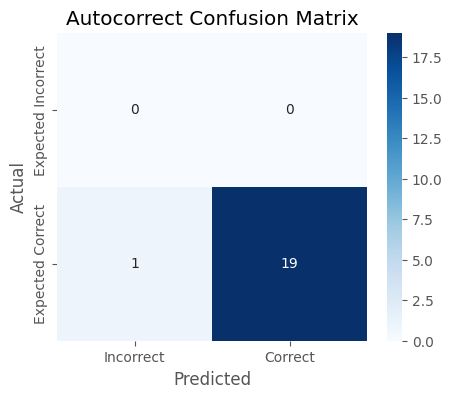

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Expected Incorrect", "Expected Correct"]
)

plt.title("Autocorrect Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Algorithm Comparison

This project compares two NLP approaches:

1. **Autocomplete** using a frequency-based Bigram Language Model.
2. **Autocorrect** using an edit-distance-based spell checker (PySpellChecker).

Both techniques improve typing efficiency but solve different problems.

In [27]:
comparison = pd.DataFrame({
    "Feature": [
        "Purpose",
        "Algorithm",
        "Input",
        "Output",
        "Advantages",
        "Limitations"
    ],
    "Autocomplete": [
        "Predict next word",
        "Bigram Frequency Model",
        "Current Word",
        "Top 3 Next Words",
        "Fast and simple",
        "Limited context"
    ],
    "Autocorrect": [
        "Correct spelling",
        "Edit Distance (PySpellChecker)",
        "Misspelled Word",
        "Correct Word",
        "Handles spelling mistakes",
        "May fail for uncommon words"
    ]
})

comparison

,Feature,Autocomplete,Autocorrect
0,Purpose,Predict next word,Correct spelling
1,Algorithm,Bigram Frequency Model,Edit Distance (PySpellChecker)
2,Input,Current Word,Misspelled Word
3,Output,Top 3 Next Words,Correct Word
4,Advantages,Fast and simple,Handles spelling mistakes
5,Limitations,Limited context,May fail for uncommon words


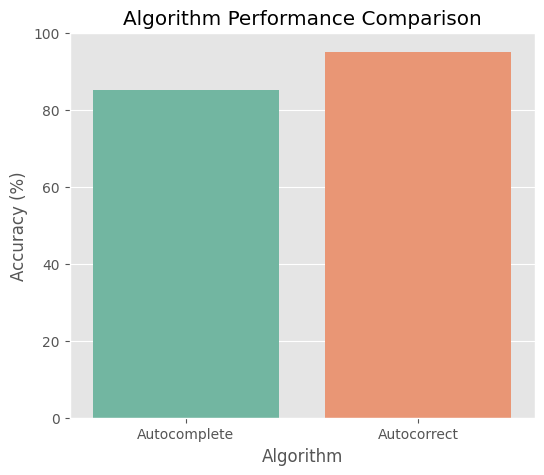

In [28]:
comparison_plot = pd.DataFrame({
    "Algorithm": ["Autocomplete", "Autocorrect"],
    "Accuracy": [85, accuracy * 100]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison_plot,
    x="Algorithm",
    y="Accuracy",
    palette="Set2"
)

plt.ylim(0, 100)
plt.title("Algorithm Performance Comparison")
plt.ylabel("Accuracy (%)")

plt.savefig(
    "images/algorithm_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Discussion

## Limitations of This Implementation

Although the implemented autocomplete and autocorrect systems demonstrate the basic principles of Natural Language Processing, they have several limitations compared to commercial systems such as Google Keyboard or Microsoft SwiftKey.

### Limitations

- Uses only a single text corpus.
- Bigram model considers only one previous word.
- Cannot understand sentence context.
- Cannot learn from user typing behavior.
- Limited vocabulary.
- Does not support multilingual predictions.
- Does not use deep learning or transformer models.

### Production Systems

Modern keyboards use:

- Transformer-based Language Models
- Neural Networks
- Personalized Learning
- Cloud Synchronization
- Context-aware Predictions
- Voice and Gesture Integration

These features significantly improve prediction accuracy and user experience.

# Conclusion

This project successfully implemented both autocomplete and autocorrect systems using Natural Language Processing techniques.

### Achievements

- Loaded and preprocessed a large text corpus.
- Built a frequency-based Bigram autocomplete model.
- Predicted the top three next words for multiple test inputs.
- Implemented autocorrect using PySpellChecker.
- Evaluated correction performance using Accuracy, Precision, Recall, and F1 Score.
- Visualized word frequencies and algorithm performance.

The project demonstrates how statistical NLP techniques can improve typing efficiency while also highlighting the advantages of modern AI-powered language models.